In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('heart.csv')

# Separate features (X) and target (y)
X = df.drop('target', axis=1)  # Assuming 'target' is the name of the target column
y = df['target']

# Perform train_test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (820, 13)
X_test shape: (205, 13)
y_train shape: (820,)
y_test shape: (205,)


In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [4]:
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [5]:
y_pred = rf.predict(X_test)

In [6]:
accuracy_score(y_test,y_pred)

0.8731707317073171

In [7]:
importance = rf.feature_importances_
features = X.columns

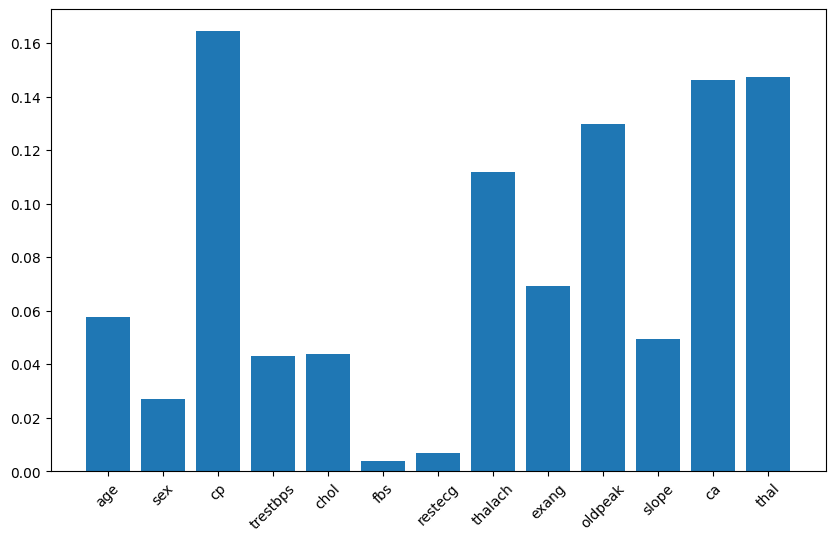

In [9]:
plt.figure(figsize=(10,6))
plt.bar(features,importance)
plt.xticks(rotation=45)
plt.show()

In [14]:
from sklearn.tree import plot_tree


[Text(0.5681818181818182, 0.9166666666666666, 'slope <= 1.5\ngini = 0.499\nsamples = 514\nvalue = [390, 430]\nclass = Disease'),
 Text(0.3352272727272727, 0.75, 'thal <= 2.5\ngini = 0.462\nsamples = 287\nvalue = [289, 164]\nclass = No Disease'),
 Text(0.45170454545454547, 0.8333333333333333, 'True  '),
 Text(0.18181818181818182, 0.5833333333333334, 'ca <= 0.5\ngini = 0.489\nsamples = 143\nvalue = [99, 134]\nclass = Disease'),
 Text(0.09090909090909091, 0.4166666666666667, 'oldpeak <= 2.7\ngini = 0.282\nsamples = 84\nvalue = [24, 117]\nclass = Disease'),
 Text(0.045454545454545456, 0.25, 'cp <= 1.5\ngini = 0.203\nsamples = 78\nvalue = [15, 116]\nclass = Disease'),
 Text(0.022727272727272728, 0.08333333333333333, 'gini = 0.34\nsamples = 42\nvalue = [15, 54]\nclass = Disease'),
 Text(0.06818181818181818, 0.08333333333333333, 'gini = 0.0\nsamples = 36\nvalue = [0, 62]\nclass = Disease'),
 Text(0.13636363636363635, 0.25, 'cp <= 1.0\ngini = 0.18\nsamples = 6\nvalue = [9, 1]\nclass = No Disea

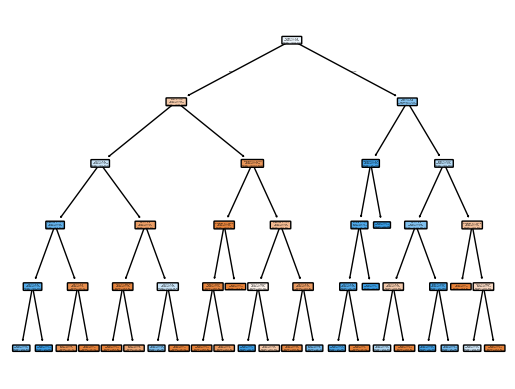

In [19]:
plot_tree(
    rf.estimators_[49],
    feature_names = X.columns,
    class_names = ['No Disease', 'Disease'],
    filled=True,
    rounded=True
)

Random forest: is a collection of many decision trees.

the idea of multiple algorithms and then voting is called "Ensemble learning"

Each tree is given slightly different data (random)

Types of Randomness:

1. Random Data Sampling / Bootstrap Sampling

1000 patients

Tree 1: 1-50
Tree 2: 51-100
Tree 3: 101-150....

2. Random Feature Selection
Each tree also sees only random features during splitting.

Tree 1: Cholesterol / Age
Tree 2: Heart rate / chest pain
Tree 3: Blood pressure / ECG readings

Voting Mechanism:

Majority Wins

Hyperparameters in RF:

n_estimators: How many trees should exist in the forest.
max_depth: Controls tree complexity
random_state:Control reproducibility


Feature Importance: RF can estimate feature importance.